ML PRACTICAL 2 --- LINEAR REGRESSION

In [ ]:
import numpy as np

x = np.array([1,2,3,4,5])
y = np.array([14,20,25,29,34])

m_curr = b_curr = 0
n = len(x)


In [ ]:
iter = 500
learning_rate = 0.005

for i in range(iter):
  y_pred = m_curr * x + b_curr
  md = -(2/n)*sum(x*(y-y_pred))
  bd = -(2/n)*sum(y-y_pred)
  cost = (1/n)*sum([val**2 for val in (y-y_pred)])
  m_curr = m_curr - learning_rate * md
  b_curr = b_curr - learning_rate * bd

print("m : {} b: {}, cost:{} ".format(m_curr,b_curr,cost))


m : 5.29525254726122 b: 8.273012891432884, cost:0.5918971151500462 


In [ ]:
MULTIVARIATE GD

In [6]:
import numpy as np
import pandas as pd
from sklearn import datasets, metrics
from numpy.linalg import inv, pinv, LinAlgError
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [7]:
X, y = datasets.load_boston(return_X_y=True)
X_train_temp1=X[0:400,:]
X_train=np.zeros((X_train_temp1.shape[0],X_train_temp1.shape[1]+1))
X_train[:,0]=np.ones((X_train_temp1.shape[0]))
X_train[:,1:]=X_train_temp1
y_train=y[0:400]

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

linear Regression wit sklearn

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pandas as pd
import numpy as np

# Load the data
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Process the data to extract features and target
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
X = data[:, :-1]  # Extracting all columns except the last one as features
y = data[:, -1]   # The last column as the target variable

# Splitting the data into training and test sets
X_train_temp1 = X[0:400, :]
X_train = np.zeros((X_train_temp1.shape[0], X_train_temp1.shape[1] + 1))
X_train[:, 0] = 1  # Adding a bias term (column of ones)
X_train[:, 1:] = X_train_temp1
y_train = y[0:400]

X_test_temp1 = X[400:, :]
X_test = np.zeros((X_test_temp1.shape[0], X_test_temp1.shape[1] + 1))
X_test[:, 0] = 1  # Adding a bias term (column of ones)
X_test[:, 1:] = X_test_temp1
y_test = y[400:]

# Train the Linear Regression model
reg = LinearRegression().fit(X_train, y_train)

# Evaluate the model on the training data
training_score = reg.score(X_train, y_train)

# Print coefficients and intercept
print("Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)

# Make predictions on the test data
pred = reg.predict(X_test)

# Calculate evaluation metrics
MAE = metrics.mean_absolute_error(y_true=y_test, y_pred=pred)
MSE = metrics.mean_squared_error(y_true=y_test, y_pred=pred)

# Print the results
print("Training Score: ", training_score)
print("Mean Absolute Error (MAE):", MAE)
print("Mean Squared Error (MSE):", MSE)




Coefficients: [ 0.00000000e+00  2.19394929e-01  1.33625708e-02  1.01626769e-01
 -5.27038350e-01  6.03487241e+00 -4.65408704e+00  8.83688545e-02
  1.70351148e-01 -2.97859874e-02 -3.47567912e-03  8.82613436e-02
  8.66193976e-03]
Intercept: 26.208897178441894
Training Score:  0.6431566406724775
Mean Absolute Error (MAE): 4.7565204631901326
Mean Squared Error (MSE): 38.093432375190346


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load the dataset from the URL
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[

]

# Column names for the dataset
column_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

# Creating a DataFrame for the features
features_df = pd.DataFrame(data, columns=column_names)

# Adding the target variable to the DataFrame
features_df['MEDV'] = target

# Splitting the features and target variable from the DataFrame
X = features_df.iloc[:, :-1].values  # All columns except the last one
y = features_df['MEDV'].values  # The last column

# Splitting the dataset into training and testing sets
X_train_temp1, X_test, y_train, y_test = train_test_split(X, y, train_size=400, random_state=42)

# Adding a column of ones to the training set for the intercept term
X_train = np.zeros((X_train_temp1.shape[0], X_train_temp1.shape[1] + 1))
X_train[:, 0] = np.ones(X_train_temp1.shape[0])
X_train[:, 1:] = X_train_temp1

# Verify shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (400, 14)
y_train shape: (400,)
X_test shape: (106, 13)
y_test shape: (106,)


In [ ]:
X_test_temp1=X[400:506,:]
X_test=np.zeros((X_test_temp1.shape[0],X_test_temp1.shape[1]+1))
X_test[:,0]=np.ones((X_test_temp1.shape[0]))
X_test[:,1:]=X_test_temp1


In [ ]:
y_test=y[400:506]
scaler=StandardScaler()
scaler.fit(X_train[:,1:])
X_train[:,1:]=scaler.transform(X_train[:,1:])
X_test[:,1:]=scaler.transform(X_test[:,1:])
theta=np.random.uniform(0,1,size=(X_train.shape[1]))
m=X_train.shape[0]
n=X_train.shape[1]
f = plt.figure()
f.set_figwidth(4)
f.set_figheight(1)


<Figure size 400x100 with 0 Axes>

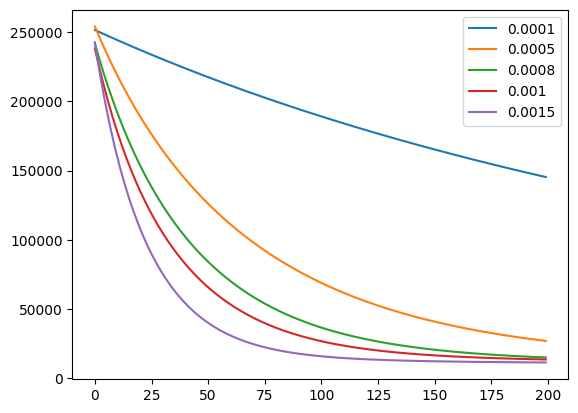

In [ ]:
iterations= 200
alpha_arr = [0.0001,0.0005,0.0008,0.001,0.0015]
# alpha_arr = [0.01,0.001,0.0008,0.0005,0.0001]

for alpha_I in range(len(alpha_arr)):
  alpha = alpha_arr[alpha_I]
  theta=np.random.uniform(0,1,size=(X_train.shape[1]))
  err=[]
  count=[]
  for i in range(iterations):
    update= np.zeros(X_train.shape[1])
    ypred = np.dot(X_train,theta)
    predError = ypred - y_train
    err.append(np.sum(np.square(predError)));
    count.append(i);
    for j in range(n):
      update[j]=np.sum(predError*(X_train.T)[j])
      theta = theta - (1/m)*(alpha)*update
  plt.plot(np.array(count),np.array(err))
  plt.legend(alpha_arr)
plt.show()


In [ ]:
predictions = np.dot(X_test, theta)
print("MAE:", metrics.mean_absolute_error(y_true=y_test,y_pred=predictions))
print("MSE:", metrics.mean_squared_error(y_true=y_test,y_pred=predictions))


MAE: 3.6486054189079664
MSE: 21.68436907410154


# REEGULARISATION WITHOUT SKLEARN

L = np.identity(n): This creates an identity matrix of size n x n. An identity matrix is a square matrix with ones on the diagonal and zeros elsewhere.
L[0][0] = 0: The first element on the diagonal is set to 0. This step might be done to exclude the intercept (bias term) from regularization.
L = lamda * L: The identity matrix L is multiplied by the current λλ value. This is the regularization term that will be added to the linear regression equation.

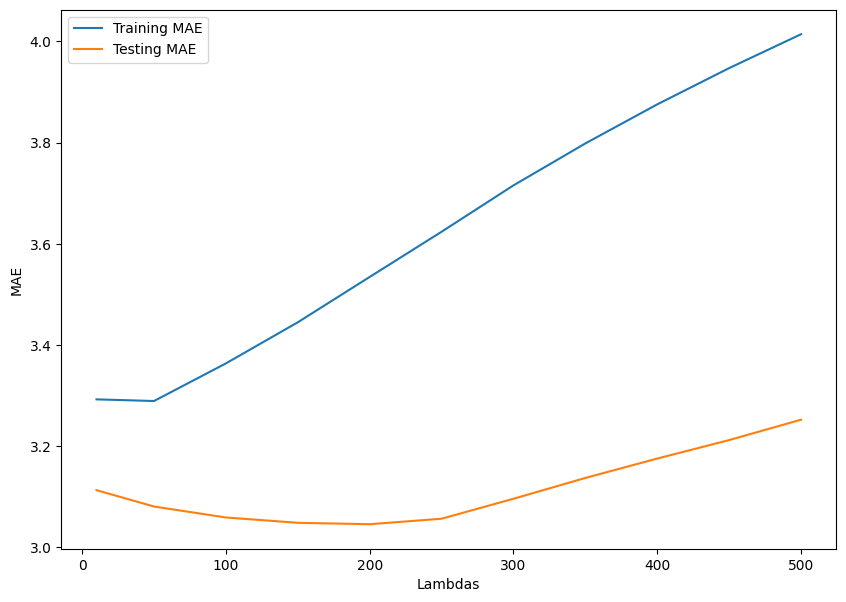

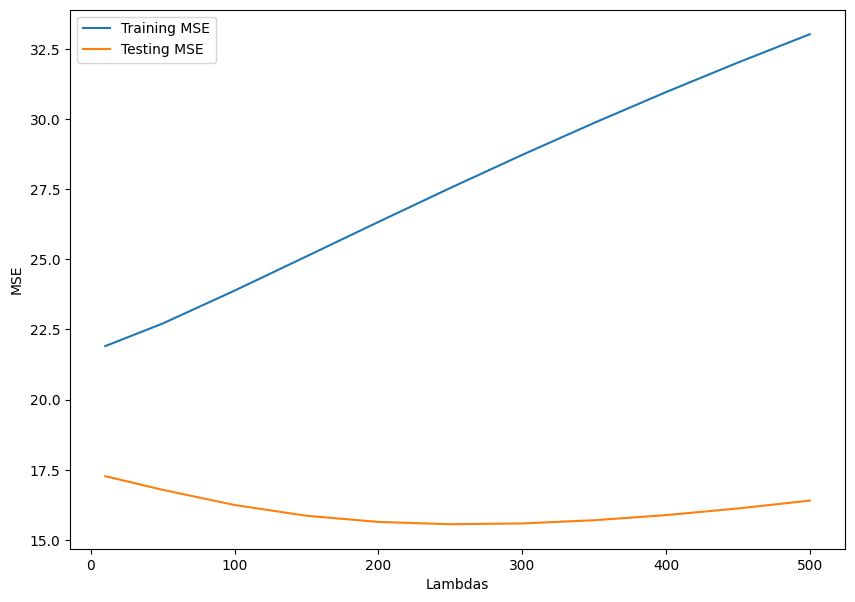

In [ ]:
lamdas = [10,50,100,150,200,250,300,350,400,450,500]
train_mae = []
test_mae = []

train_mse = []
test_mse = []
for lamda in lamdas:
  try:
    L = np.identity(n) #L = np.identity(n): This creates an identity matrix of size n x n.
    L[0][0] = 0 #L[0][0] = 0: The first element on the diagonal is set to 0.
    L = lamda*L
    XTXi=inv(np.dot(X_train.T,X_train) + L)
  except LinAlgError:
    XTXi=pinv(np.dot(X_train.T,X_train)+L)

  XTy=np.dot(X_train.T,y_train)
  theta=np.dot(XTXi,XTy)

  predictions=np.dot(theta,X_test.T)
  pred_training = np.dot(theta,X_train.T)

  a = metrics.mean_absolute_error(y_true=y_train,y_pred=pred_training)
  b =  metrics.mean_absolute_error(y_true=y_test,y_pred=predictions)
  train_mae.append(a)
  test_mae.append(b)

  c = metrics.mean_squared_error(y_true=y_train,y_pred=pred_training)
  d =  metrics.mean_squared_error(y_true=y_test,y_pred=predictions)
  train_mse.append(c)
  test_mse.append(d)

f = plt.figure()
f.set_figwidth(10)
f.set_figheight(7)

plt.plot(lamdas,train_mae,label="Training MAE")
plt.xlabel("Lambdas")
plt.ylabel("MAE")
plt.plot(lamdas,test_mae,label="Testing MAE")
plt.legend()
plt.show()

print()

f = plt.figure()
f.set_figwidth(10)
f.set_figheight(7)
plt.plot(lamdas,train_mse,label="Training MSE")
plt.xlabel("Lambdas")
plt.ylabel("MSE")
plt.plot(lamdas,test_mse,label="Testing MSE")
plt.legend()
plt.show()



REGULARISATION WITH SKLEARN

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)
reg.score(X_train, y_train)
#reg.coef
pred = reg.predict(X_test)
MAE = metrics.mean_absolute_error(y_true=y_test,y_pred=pred)
MSE =  metrics.mean_squared_error(y_true=y_test,y_pred=pred)
print("MAE: ",MAE)
print("MSE: ",MSE)


MAE:  3.141825084346206
MSE:  17.481303245050114


# **linear Regression using GD with sklearn**

---




In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import requests
from io import StringIO

# Load the dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
response = requests.get(data_url)
data = response.text.splitlines()

# Parse the data
header = data[0]
raw_data = data[22:]

# The data comes in two parts per sample, so we'll split and combine them
raw_data = [line.split() for line in raw_data if len(line.split()) > 0]
data_part1 = np.array([list(map(float, line)) for line in raw_data[::2]])
data_part2 = np.array([list(map(float, line)) for line in raw_data[1::2]])
data = np.hstack((data_part1, data_part2))

# The first 13 columns are the features, and the last column is the target variable
X = data[:, :-1]
y = data[:, -1]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the SGD Regressor
sgd_regressor = SGDRegressor(max_iter=1000, tol=1e-3, learning_rate='invscaling', eta0=0.01, random_state=42)

# Fit the model using gradient descent
sgd_regressor.fit(X_train, y_train)

# Predict and calculate the Mean Squared Error
y_pred = sgd_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")


Mean Squared Error: 24.875082018536872


# **NORMAL EQUATION USING SKLEARN**

In [14]:
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import requests

# Load the dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
response = requests.get(data_url)
data = response.text.splitlines()

# Parse the data
header = data[0]
raw_data = data[22:]

# The data comes in two parts per sample, so we'll split and combine them
raw_data = [line.split() for line in raw_data if len(line.split()) > 0]
data_part1 = np.array([list(map(float, line)) for line in raw_data[::2]])
data_part2 = np.array([list(map(float, line)) for line in raw_data[1::2]])
data = np.hstack((data_part1, data_part2))

# The first 13 columns are the features, and the last column is the target variable
X = data[:, :-1]
y = data[:, -1]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the SGD Regressor with regularization (L2 regularization)
sgd_regressor = SGDRegressor(penalty='l2', alpha=0.01, max_iter=1000, tol=1e-3, learning_rate='invscaling', eta0=0.01, random_state=42)

# Fit the model using gradient descent
sgd_regressor.fit(X_train, y_train)

# Predict and calculate the Mean Squared Error
y_pred = sgd_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error with L2 Regularization: {mse}")


Mean Squared Error with L2 Regularization: 25.068400643554362


# **linear regression using normal equation**

In [15]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import requests

# Load the dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
response = requests.get(data_url)
data = response.text.splitlines()

# Parse the data
header = data[0]
raw_data = data[22:]

# The data comes in two parts per sample, so we'll split and combine them
raw_data = [line.split() for line in raw_data if len(line.split()) > 0]
data_part1 = np.array([list(map(float, line)) for line in raw_data[::2]])
data_part2 = np.array([list(map(float, line)) for line in raw_data[1::2]])
data = np.hstack((data_part1, data_part2))

# The first 13 columns are the features, and the last column is the target variable
X = data[:, :-1]
y = data[:, -1]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the Linear Regressor (using the normal equation)
linear_regressor = LinearRegression()

# Fit the model using the training data
linear_regressor.fit(X_train, y_train)

# Predict and calculate the Mean Squared Error
y_pred = linear_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (Normal Equation): {mse}")


Mean Squared Error (Normal Equation): 24.291119474973513


Linear Regression using normal equaiton with regularization

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import requests

# Load the dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
response = requests.get(data_url)
data = response.text.splitlines()

# Parse the data
header = data[0]
raw_data = data[22:]

# The data comes in two parts per sample, so we'll split and combine them
raw_data = [line.split() for line in raw_data if len(line.split()) > 0]
data_part1 = np.array([list(map(float, line)) for line in raw_data[::2]])
data_part2 = np.array([list(map(float, line)) for line in raw_data[1::2]])
data = np.hstack((data_part1, data_part2))

# The first 13 columns are the features, and the last column is the target variable
X = data[:, :-1]
y = data[:, -1]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the Ridge Regressor (using the normal equation with L2 regularization)
ridge_regressor = Ridge(alpha=0.01, solver='cholesky')

# Fit the model using the training data
ridge_regressor.fit(X_train, y_train)

# Predict and calculate the Mean Squared Error
y_pred = ridge_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error with Ridge Regularization (Normal Equation): {mse}")
